In [1]:
from HARey_constellation_cards.harey_main import HAReyMain
from HARey_constellation_cards.astro_projection import local2equator
import matplotlib.pyplot as plt
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
import numpy as np

harey = HAReyMain()

Loading constellations diagrams....     Done!
Loading star coordinates....     Done!
Computing stars colors...     Done!
Loading custom markers....       Done!
Loading the object names....       Done!


Using the tarot-round format, 2.75x4.75 in, using the template at cardbacks/tarot_round.png


In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, PathPatch
from matplotlib.path import Path

# IMPORTANTE
### NORTHERN EMISPHERE
Hour disk: anticlockwise, 12 to SOUTH
Day disk: clockwise, MARCH 20 to RA 0
### SOUTHERN EMISPHERE
Hour disk: clockwise, 12 to NORTH
Day disk: anticlockwise, MARCH 20 to RA 0


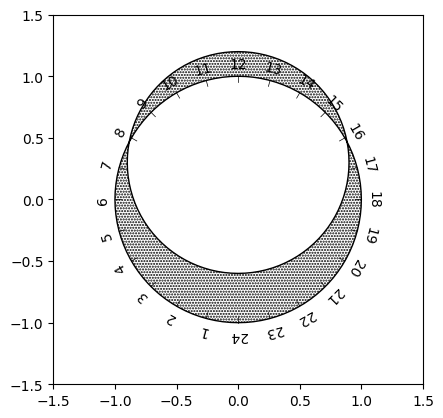

In [3]:
a = np.linspace(0, 2*np.pi, 101)
vertices = []
codes = []

# f flips the plot left and right, depending on the hemisphere
HEMISPHERE = 'S'
f = 1 if HEMISPHERE == 'N' else -1

# Outer circle points
circle = np.array((np.sin(a), np.cos(a))).transpose()
vertices.extend(circle)
codes.extend([Path.MOVETO] + [Path.LINETO]*(circle.shape[0]-2) + [Path.CLOSEPOLY])

# The internal circle is made anticlockwise to create the empty shape
cutout = np.array((0.9*np.sin(-a), 0.3+ 0.9*np.cos(-a))).transpose()
vertices.extend(cutout)
codes.extend([Path.MOVETO] + [Path.LINETO]*(cutout.shape[0]-2) + [Path.CLOSEPOLY])

# Join the two paths into a patch
mask = Path(vertices, codes)
mask = PathPatch(mask, hatch='......', fill=None)

fig, ax = plt.subplots(nrows=1, ncols=1)
# Add the hours marker
for i in range(1,25):
    a = f*i/12*np.pi
    ax.plot((1*np.sin(a),0.95*np.sin(a)), (1*np.cos(a),0.95*np.cos(a)), c='k', lw=0.5)
    ax.text(1.1*np.sin(a), -1.1*np.cos(a), f'{i}', rotation = 180 + f*i*15, ha='center', va='center', rotation_mode='anchor')
ax.add_patch(mask)
ax.set_xlim(-1.5,1.5)
ax.set_ylim(-1.5,1.5)
ax.set_aspect('equal')
plt.show()

In [4]:
from datetime import datetime
from calendar import monthrange

[]

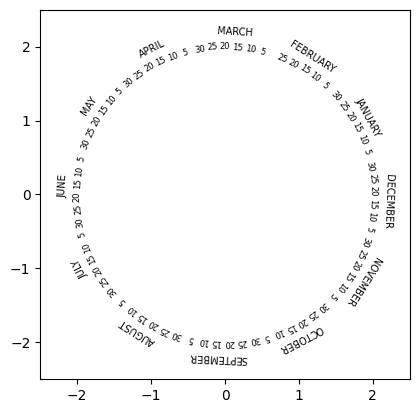

In [5]:
fig, ax = plt.subplots()
ax.set_xlim(-2.5,2.5)
ax.set_ylim(-2.5,2.5)

# Angle of the spring Equinox, which correspond to the 0 RA value
equinox_offest = datetime(2001,3,20).timetuple().tm_yday/365

for m in range(1,13):
    days_in_month = monthrange(2001,m)[1]

    # Plot the day label
    for day in range(5,days_in_month+1,5):
        # Get the angle as a fraction of the whole year
        angle = f*(datetime(2001, m, day).timetuple().tm_yday/365 - equinox_offest)
        a = 2*np.pi*angle
        ax.text(2*np.sin(a), 2*np.cos(a), f'{day}', ha='center', va='center', rotation=-angle*360, fontsize=6)

    # Plot the month label
    angle = f*((datetime(2001, m, 1).timetuple().tm_yday + days_in_month/2)/365 - equinox_offest)
    a = 2*np.pi*angle
    month_name = f'{datetime(2001,m,1).strftime('%B').upper()}'
    ax.text(2.2*np.sin(a), 2.2*np.cos(a), month_name, ha='center', va='center', rotation=-angle*360, fontsize=7)
    
ax.set_aspect('equal')
plt.plot()


In [6]:
Rz = lambda theta: np.array([[np.cos(theta), -np.sin(theta), 0],[np.sin(theta), np.cos(theta), 0 ], [0,0,1]])

Ry = lambda phi: np.array(([[np.cos(phi), 0, np.sin(phi)],[0,1,0], [-np.sin(phi), 0, np.cos(phi)]]))

def sph2cart(long, lat, r=1):
    return r*np.cos(lat)*np.cos(long), r*np.cos(lat)*np.sin(long), r*np.sin(lat)

def cart2sph(v):
    x, y, z = v[0], v[1], v[2]
    return (np.arcsin(z/np.sqrt(x**2+y**2+z**2)), np.arctan2(y,x))

def stereo_polar(phi, theta):
    theta, phi = np.deg2rad(theta), np.deg2rad(phi)
    r = np.tan(np.pi/4-theta/2)
    x, y = r*np.cos(phi), r*np.sin(phi)
    return -y, -x

def stereo_centered(long, lat, lat0, long0):
    lat, long = np.deg2rad(lat), np.deg2rad(long)
    lat0, long0 = np.deg2rad(lat0), np.deg2rad(long0)

    # Rotate the spherical coordinates
    R = np.matmul(Ry(lat0-np.pi/2), Rz(-long0))
    x,y,z = sph2cart(long, lat)
    x,y,z = np.dot(R, (x,y,z))

    # As the values are already in cartesian form, the stereo projection becomes (x/(z+1), y/(z+1))
    # This map has x-positive towards south, y-positive towards east
    # I rotate the plot to have y-positive towards north, x-positive toward west
    return (-y/(z+1), -x/(z+1))

In [7]:
stereo_polar((70,70,70), (-10,0,10))

(array([-1.11988206, -0.93969262, -0.78849573]),
 array([-0.40760373, -0.34202014, -0.28698898]))

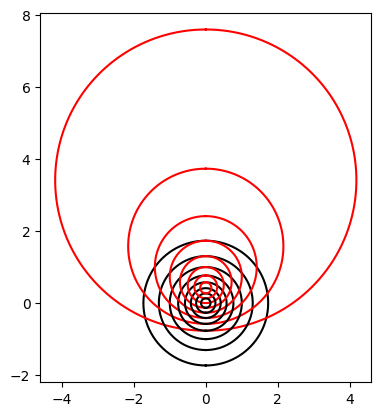

In [8]:
fig, ax = plt.subplots()
phi = np.linspace(0,360,1000)
for theta in range(-30,90,15):

    x,y = stereo_polar(phi, np.full(1000, theta))
    ax.plot(x,y, color='k')

    x,y = stereo_centered(phi, np.full(1000, theta), 45, 180)
    ax.plot(x,y, color='r')

ax.set_aspect('equal')
plt.show()

In [9]:
def azimuthal_polar(phi, theta):
    """ 
    Project a point using an azimuthal projection.

    Args:
        phi (float): Longitude of the point to project in degrees
        theta (float): Latitude of the point to project in degrees

    Returns:
        tuple: The projected coordinates (x,y) of the point on the plane, with direction (west,north)
    """
    # Convert degrees in radians
    theta, phi = np.deg2rad(theta), np.deg2rad(phi)
    # Get the distance from the centerr
    azimuth_radius = np.pi/2-theta
    x, y = azimuth_radius*np.cos(phi), azimuth_radius*np.sin(phi)
    # The projection has directions south:east. Return the projection with west:north reference 
    return -y, -x



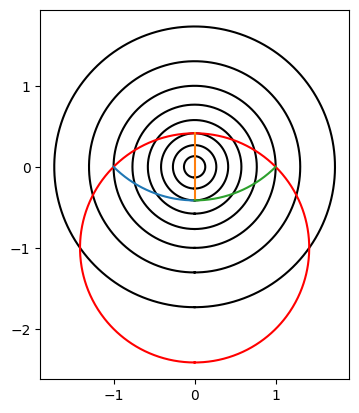

In [10]:
fig, ax = plt.subplots()
phi = np.linspace(0,360,1000)
for theta in range(-30,90,15):

    x,y = stereo_polar(phi, np.full(1000, theta))
    ax.plot(x,y, color='k')

x,y = local2equator(np.linspace(0,360,1000), np.full(1000, 0), 45, mode='stereo')
ax.plot(x,y, color='r')

for phi in range(90,360,90):
    x,y = local2equator(np.full(1000,phi), np.linspace(0,90,1000), 45, mode='stereo')
    ax.plot(x,y)

ax.set_aspect('equal')
plt.show()

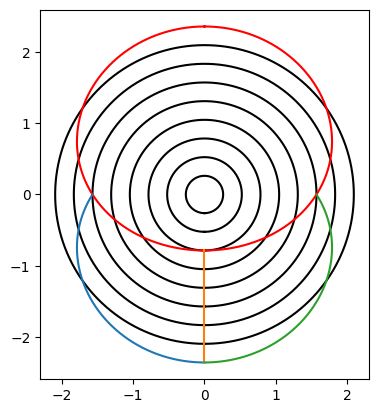

In [11]:
fig, ax = plt.subplots()
phi = np.linspace(0,360,1000)
for theta in range(-30,90,15):

    x,y = azimuthal_polar(phi, np.full(1000, theta))
    ax.plot(x,y, color='k')

x,y = local2equator(np.linspace(0,360,1000), np.full(1000, 0), -45, pole='N')
ax.plot(x,y, color='r')

for phi in range(90,360,90):
    x,y = local2equator(np.full(1000,phi), np.linspace(0,90,1000), -45, pole='N')
    ax.plot(x,y)

ax.set_aspect('equal')
plt.show()

In [12]:
def text_place(text, ax, xy, angle, font_size):

    text_path = TextPath((0, 0), text, size=font_size)
    bb = text_path.get_extents()
    text_centered = Affine2D().translate(-0.5 * (bb.x0 + bb.x1), -0.5 * (bb.y0 + bb.y1)).transform_path(text_path)
    x, y = xy
    # Rotate and move the path to its position

    trans = (Affine2D().rotate(angle).translate(x, y))
    patch = PathPatch(text_centered, transform=trans + ax.transData, color='black', linewidth=0)
    ax.add_patch(patch)


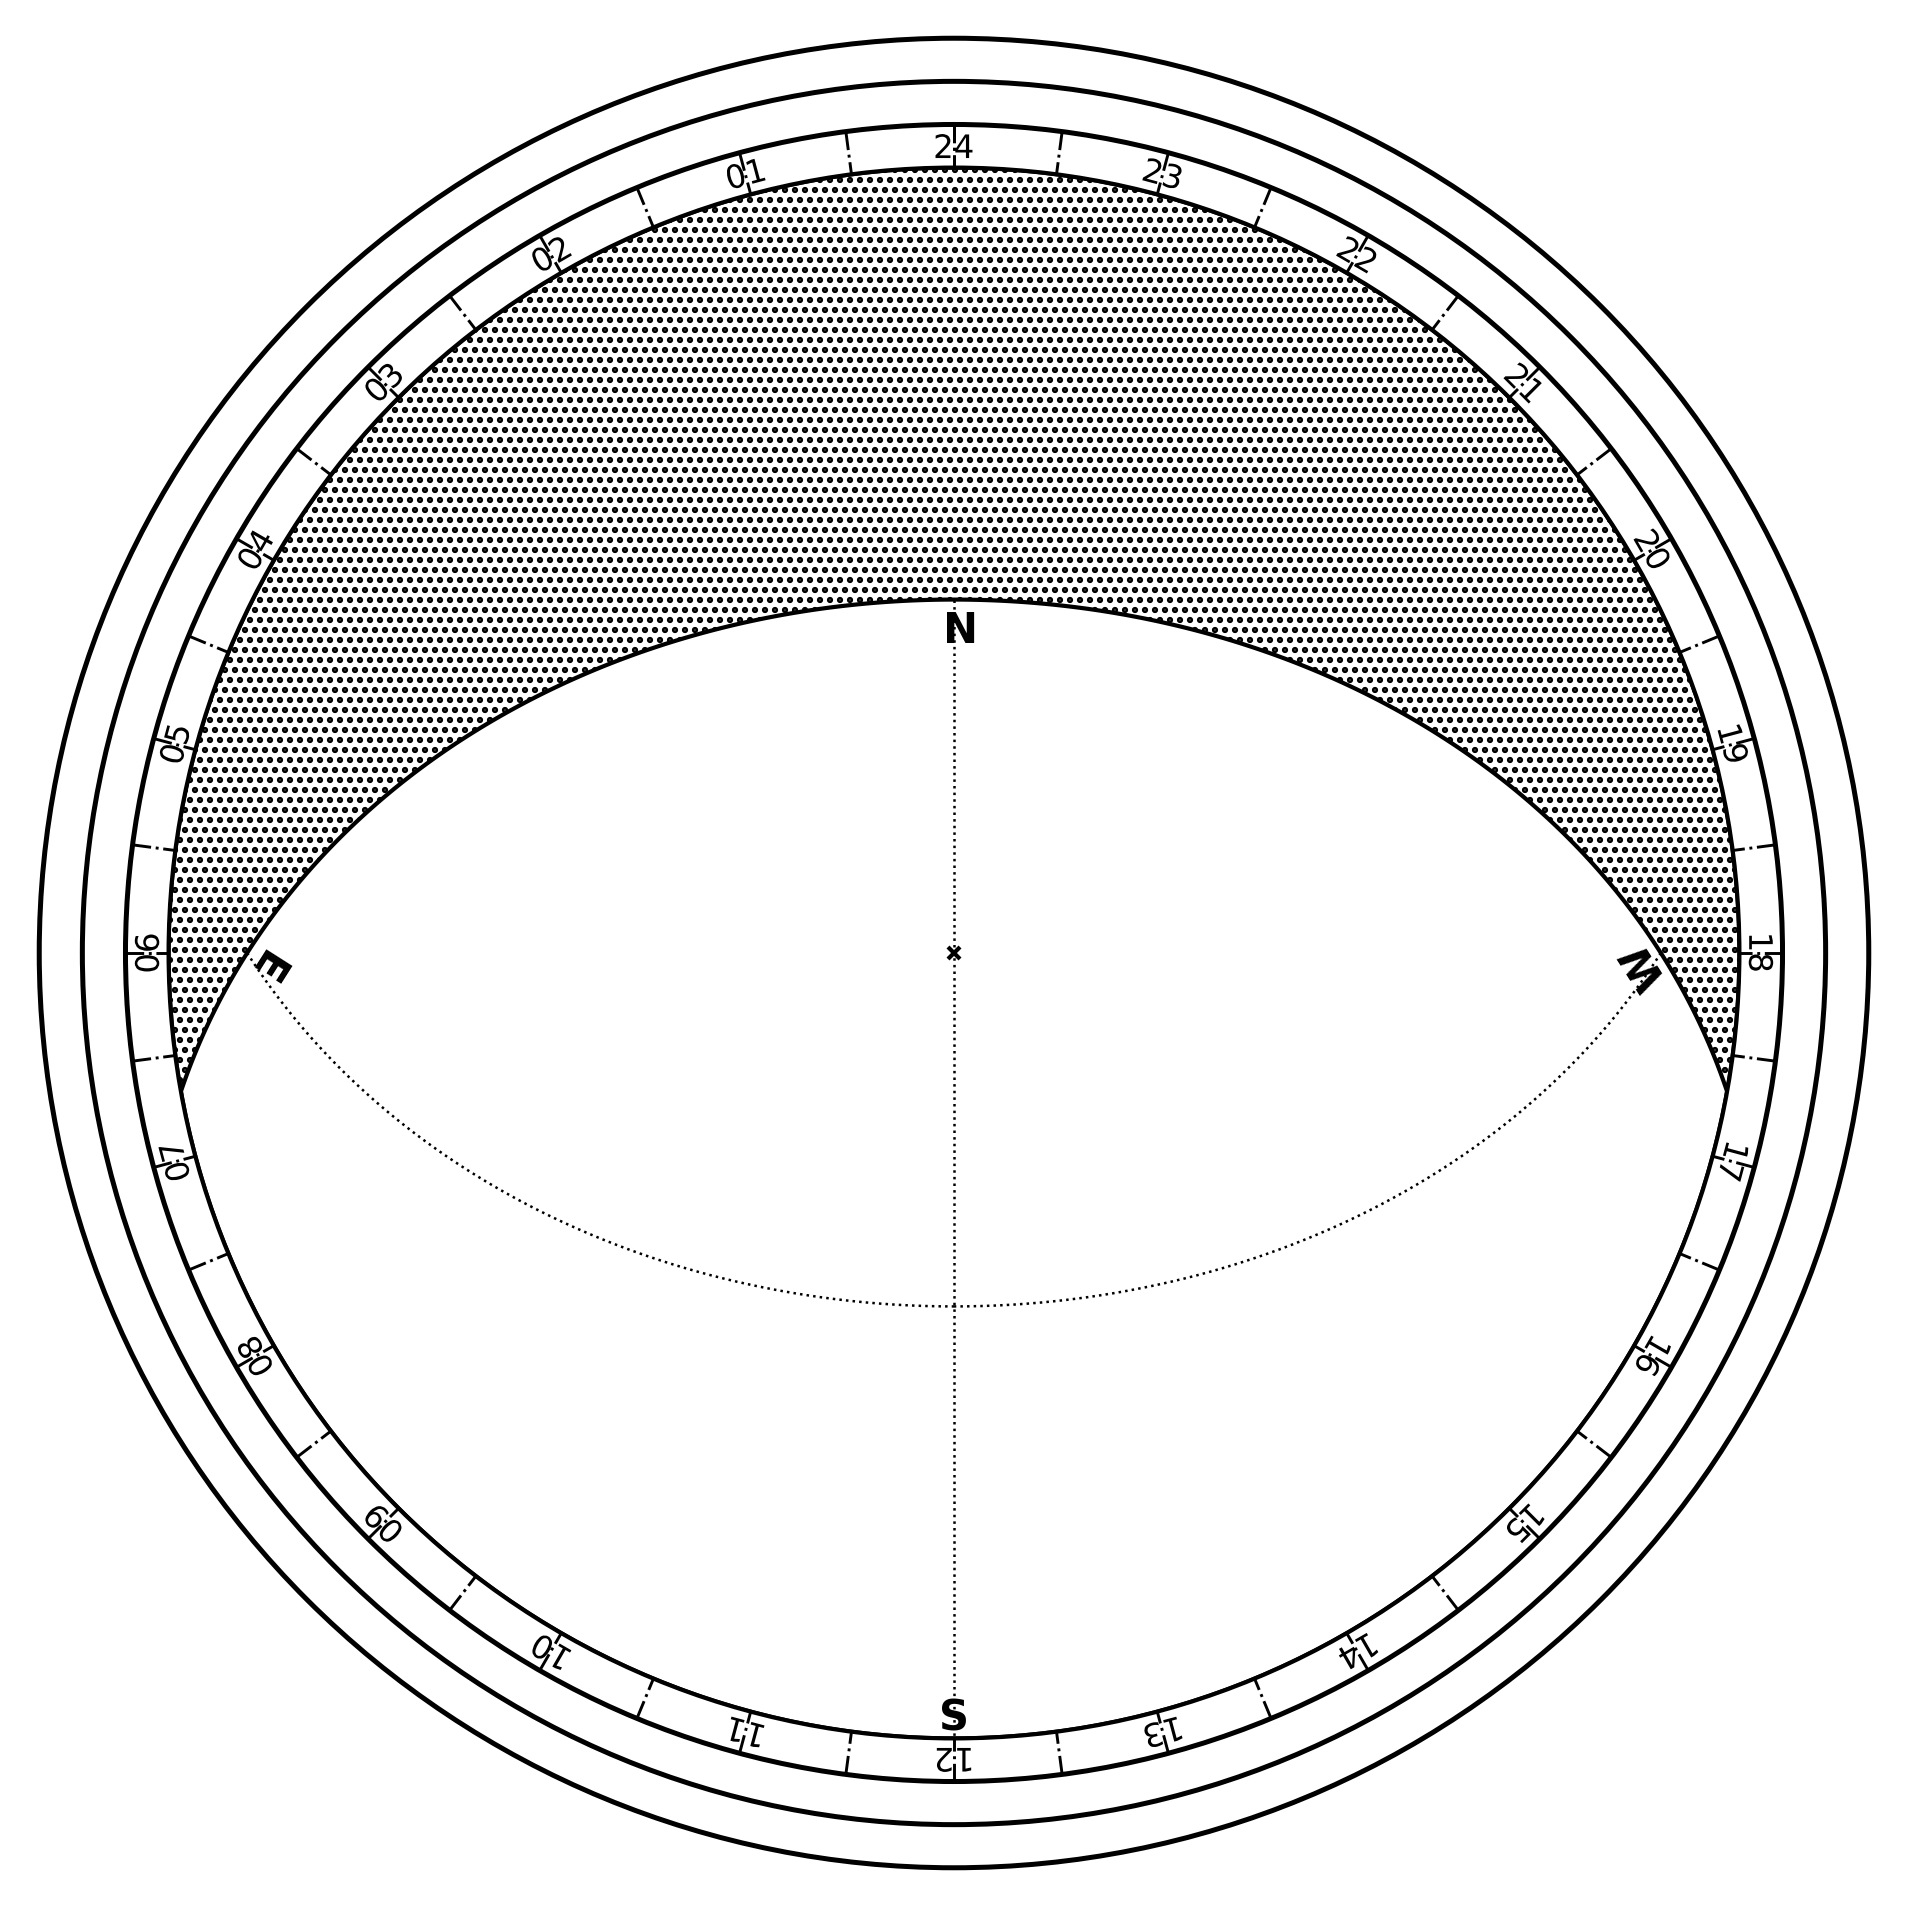

In [13]:

def plot_mask(lat, fov=210, mode='azimuth', face='front'):

    if lat == 0:
        # The equator breaks the projection, so instead of 0 a very small value is used
        lat = 1e-2

    pole = 'S' if lat < 0 else 'N'
    pole_sign = np.sign(lat)
    face_sign = 1 if face=='front' else -1
    sign = pole_sign*face_sign

    lat = sign*lat
    max_dec = (180-fov)/2

    if mode == 'stereo':
        # External circle
        ec_x, ec_y = stereo_polar(np.linspace(0,360,1001), np.full(1001, max_dec))
        _, circle_radius = stereo_polar(180, max_dec)
    else:
        # External circle
        ec_x, ec_y = azimuthal_polar(np.linspace(0,360,1001), np.full(1001, max_dec))
        _, circle_radius = azimuthal_polar(180, max_dec)
               
    # Horizon (points done anticlockwise to make the cutout)
    h_x, h_y = local2equator(np.linspace(360,0,1001), np.full(1001, 0), lat, mode=mode)

    # Meridians (east and west)
    M_x, M_y = [], []
    for phi in (90,-90):
        m_x, m_y = local2equator(np.full(1001, phi), np.linspace(0,90,1001), lat, mode=mode)
        M_x.append(m_x)
        M_y.append(m_y)

    # East and west cardinal points and angles
    e_long = sign*90
    e_x, e_y = local2equator(e_long,0,lat, mode=mode)
    x,y = local2equator((e_long+1,e_long-1), (0,0), lat)
    e_angle = np.rad2deg(np.arctan2(y[1]-y[0], x[1]-x[0]))

    w_long = -sign*90
    w_x, w_y = local2equator(w_long,0,lat, mode=mode)
    x,y = local2equator((w_long+1,w_long-1), (0,0), lat)
    w_angle = np.rad2deg(np.arctan2(y[1]-y[0], x[1]-x[0]))

    # North cardinal point (from the north emisphere)
    _, n_y = local2equator(180,0,lat, mode=mode)
    n_angle = 180
    
    # South cardinal point
    _, s_y = local2equator(0,0, lat, mode=mode)
    s_y = max(s_y, -circle_radius)
    s_angle = 0

    # From the southern emispere, north and south points are switched
    if sign<0:
        n_y, n_angle, s_y, s_angle =  s_y, s_angle, n_y, n_angle  



    int_r = 0.85
    ext_r = 0.99
    scale = int_r/circle_radius

    # Create the shape
    vertices = []
    codes = []

    if face=='front':
        # With the front face, the horizon is created as a cutout from the whole circle
        vertices.extend(np.array([scale*ec_x, scale*ec_y]).transpose())
        codes.extend([Path.MOVETO] + [Path.LINETO]*(len(ec_x)-2) + [Path.CLOSEPOLY])
        vertices.extend(np.array([scale*h_x, scale*h_y]).transpose())
        codes.extend([Path.MOVETO] + [Path.LINETO]*(len(h_x)-2) + [Path.CLOSEPOLY])

    else:
        # The back face instead the horizon is a convex figure, done in one pass only
        vertices.extend(np.array([scale*h_x, scale*h_y]).transpose())
        codes.extend([Path.MOVETO] + [Path.LINETO]*(len(h_x)-2) + [Path.CLOSEPOLY])

    mask = Path(vertices, codes)
    mask = PathPatch(mask, hatch='.....', facecolor='none', edgecolor='k')
    
    clip_circle = Circle((0,0), int_r, facecolor='none', edgecolor='k')

    fig, ax = plt.subplots(figsize=(8,8), dpi=300)
    ax.add_patch(mask)
    ax.add_patch(clip_circle)
    mask.set_clip_path(clip_circle)

    for m_x, m_y in zip(M_x, M_y):
        meridian, = ax.plot(scale*m_x, scale*m_y, color='k', lw=0.6, ls=':')
        meridian.set_clip_path(clip_circle)

    # North-south meridian   
    if face=='front':
        ax.plot((0,0), (scale*n_y, scale*s_y), color='k', lw=0.6, ls=':')
    else:
        s = 1 if pole=='N' else -1
        ax.plot((0,0), (scale*n_y, s*int_r), color='k', lw=0.6, ls=':')
        ax.plot((0,0), (scale*s_y, -s*int_r), color='k', lw=0.6, ls=':')
    
    # Plot cardinal points
    ax.text(scale*e_x, scale*e_y, 'E', rotation=e_angle, ha='center', va='bottom', rotation_mode='anchor', fontsize=10, weight='bold')
    ax.text(scale*w_x, scale*w_y, 'W', rotation=w_angle, ha='center', va='bottom', rotation_mode='anchor', fontsize=10, weight='bold')

    # Do not display the markers is outside the map
    if np.abs(scale*n_y) <= int_r:
        ax.text(0, scale*n_y, 'N', rotation=n_angle, ha='center', va='bottom', rotation_mode='anchor', fontsize=10, weight='bold')
    
    if np.abs(scale*s_y) <= int_r:
        ax.text(0, scale*s_y, 'S', rotation=s_angle, ha='center', va='bottom', rotation_mode='anchor', fontsize=10, weight='bold')

    spacing = (ext_r-int_r)/3
    for i in range(1,4):
        ax.add_patch(Circle((0,0), int_r + i*spacing, facecolor='none', edgecolor='k', lw=1.2))

    hour_r = int_r + spacing/2
    circle_r = int_r + spacing

    for hour in range(1,25):
        angle = np.pi/12*hour        
        text_place(f'{hour:02}', ax, (hour_r*np.sin(-sign*angle), hour_r*np.cos(-sign*angle)), angle=sign*angle, font_size=0.035)

    for angle in np.linspace(0,2*np.pi,49):
        ax.plot([circle_r*np.sin(angle), int_r*np.sin(angle)], [circle_r*np.cos(angle), int_r*np.cos(angle)], color='k', ls='-.', lw=0.7)

    ax.plot(0,0,'kx', lw=0, markersize=3)
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)
    ax.set_aspect('equal')
    ax.set_axis_off()
    plt.show()

plot_mask(45, fov=200, mode='azimuth', face='front')

In [14]:
stereo_polar(180, 0)

(np.float64(-1.224646799147353e-16), np.float64(0.9999999999999999))

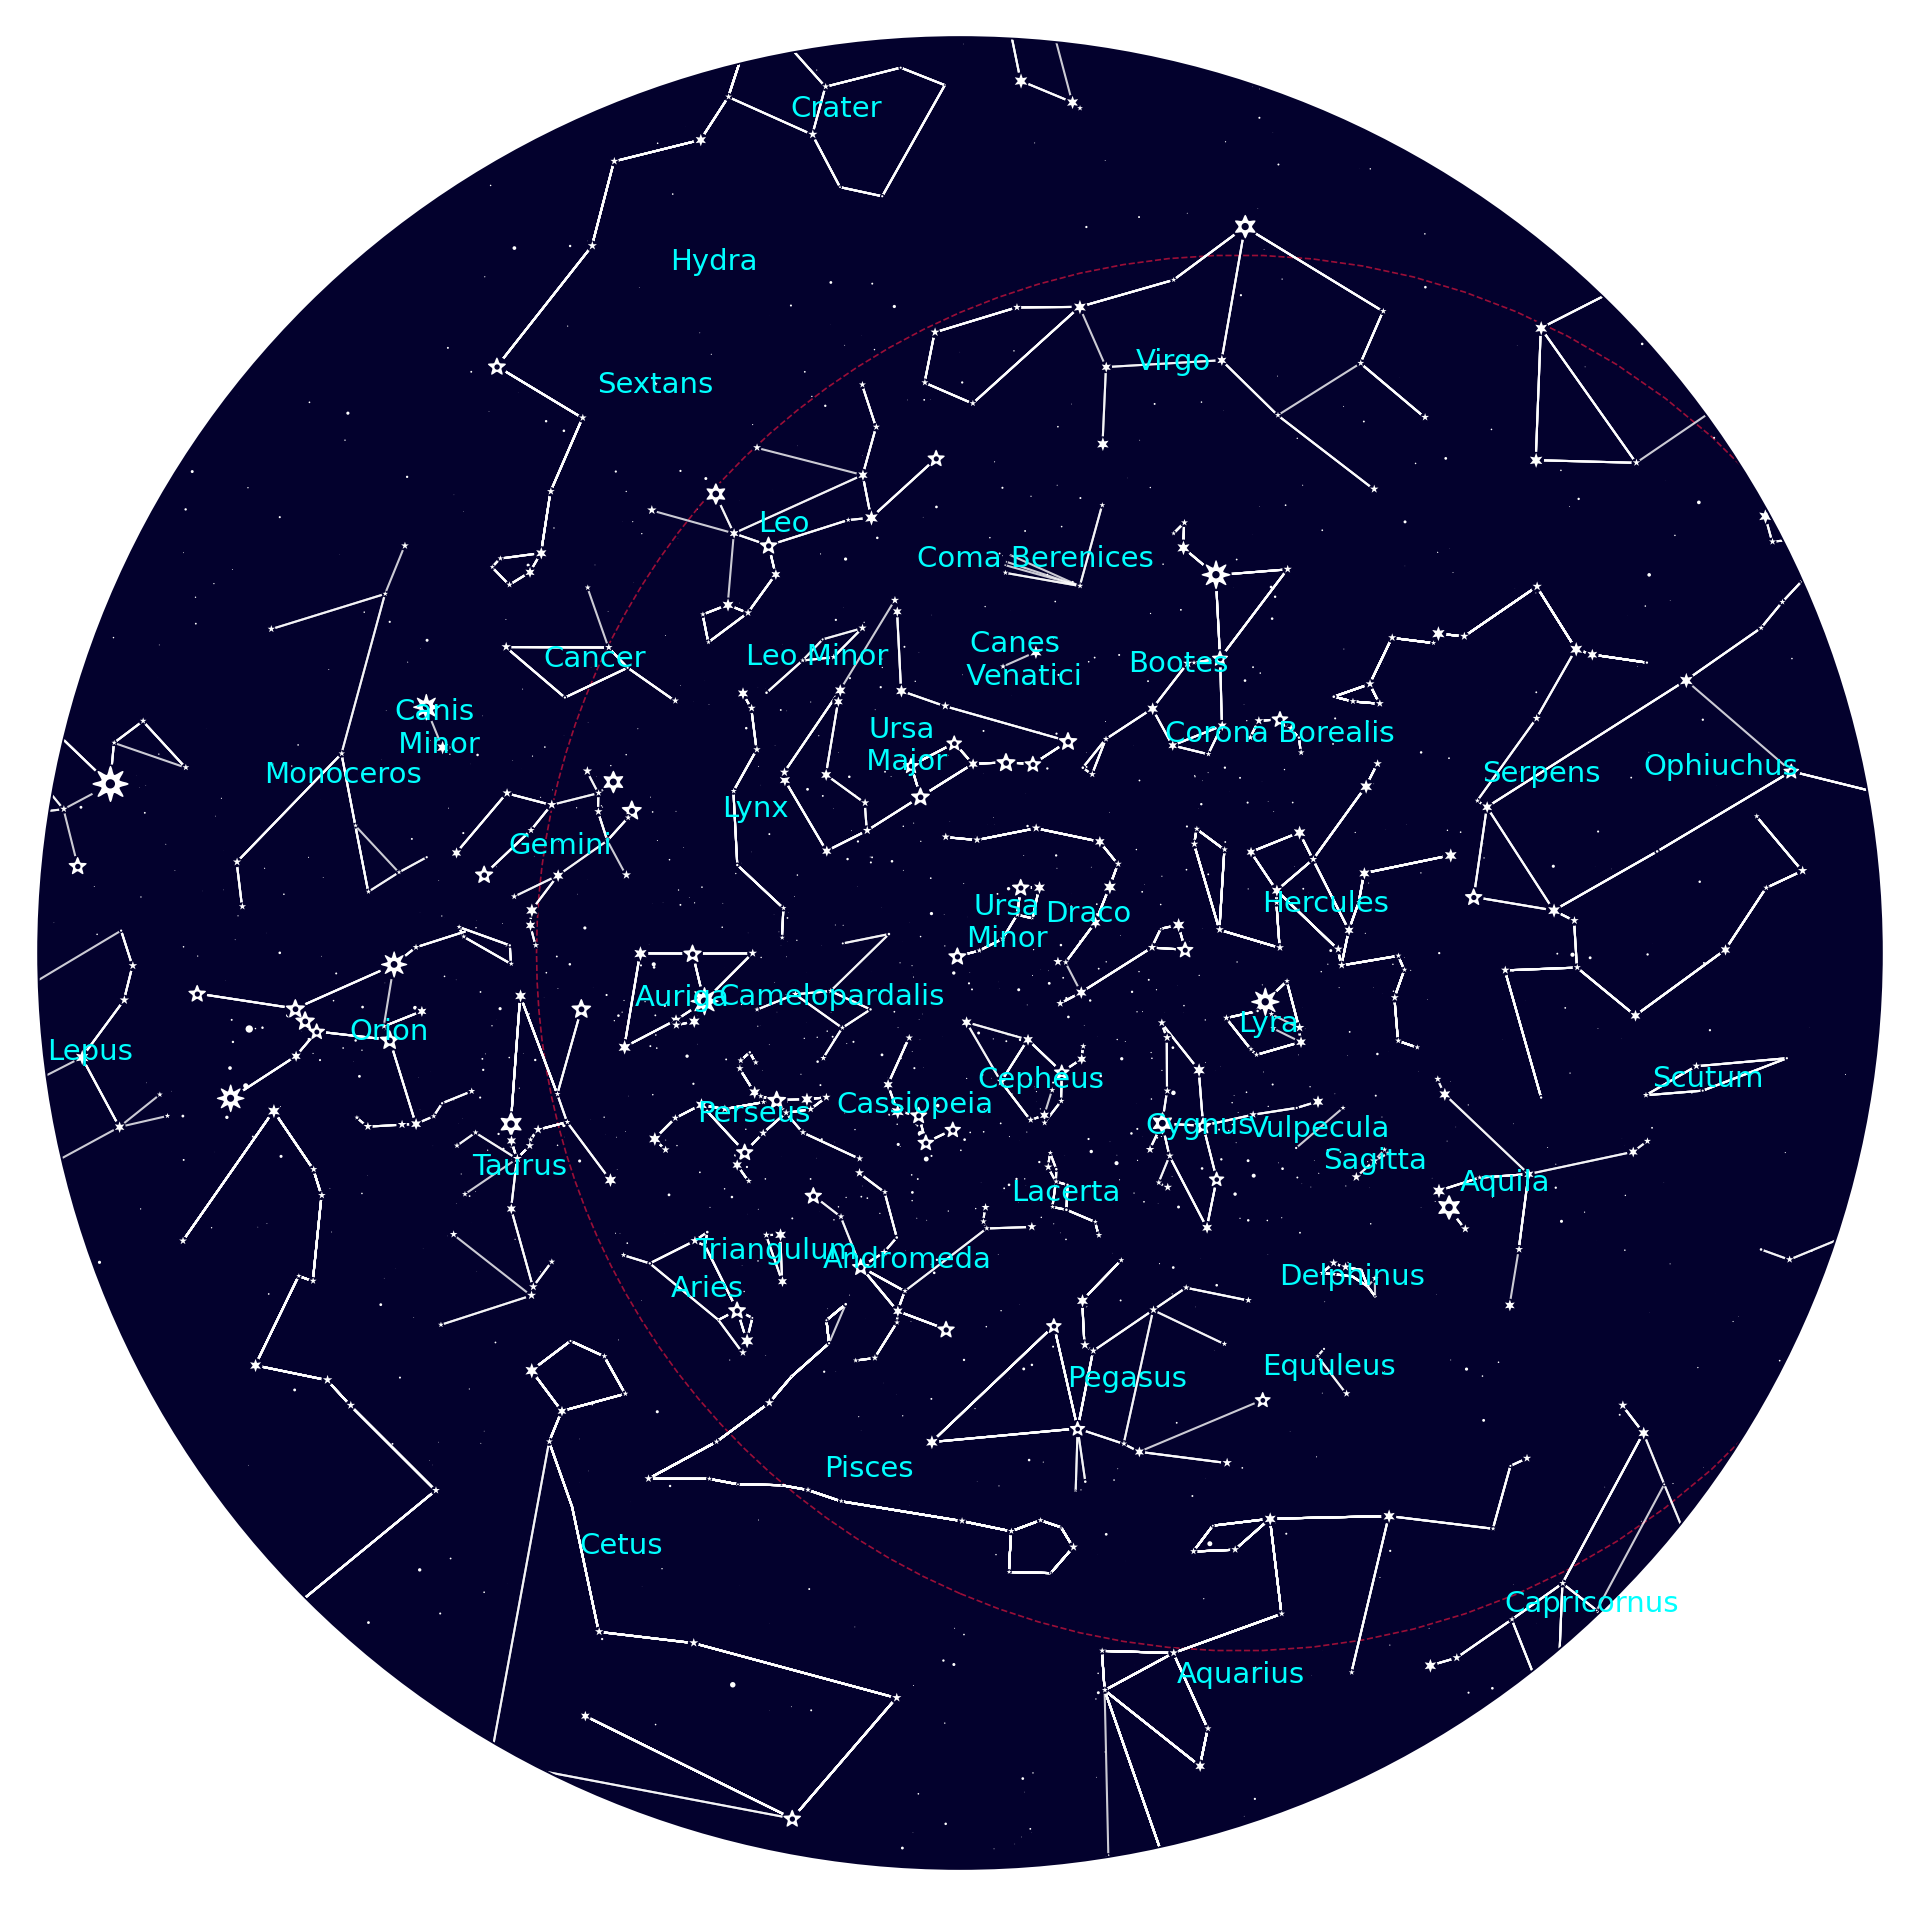

In [15]:
harey.set_limiting_magnitude(5.5)
harey.polar_map(pole='N', FOV=220, GRID=False, CON_LINES=True, mode='stereo', CON_NAMES=True, star_size=50)

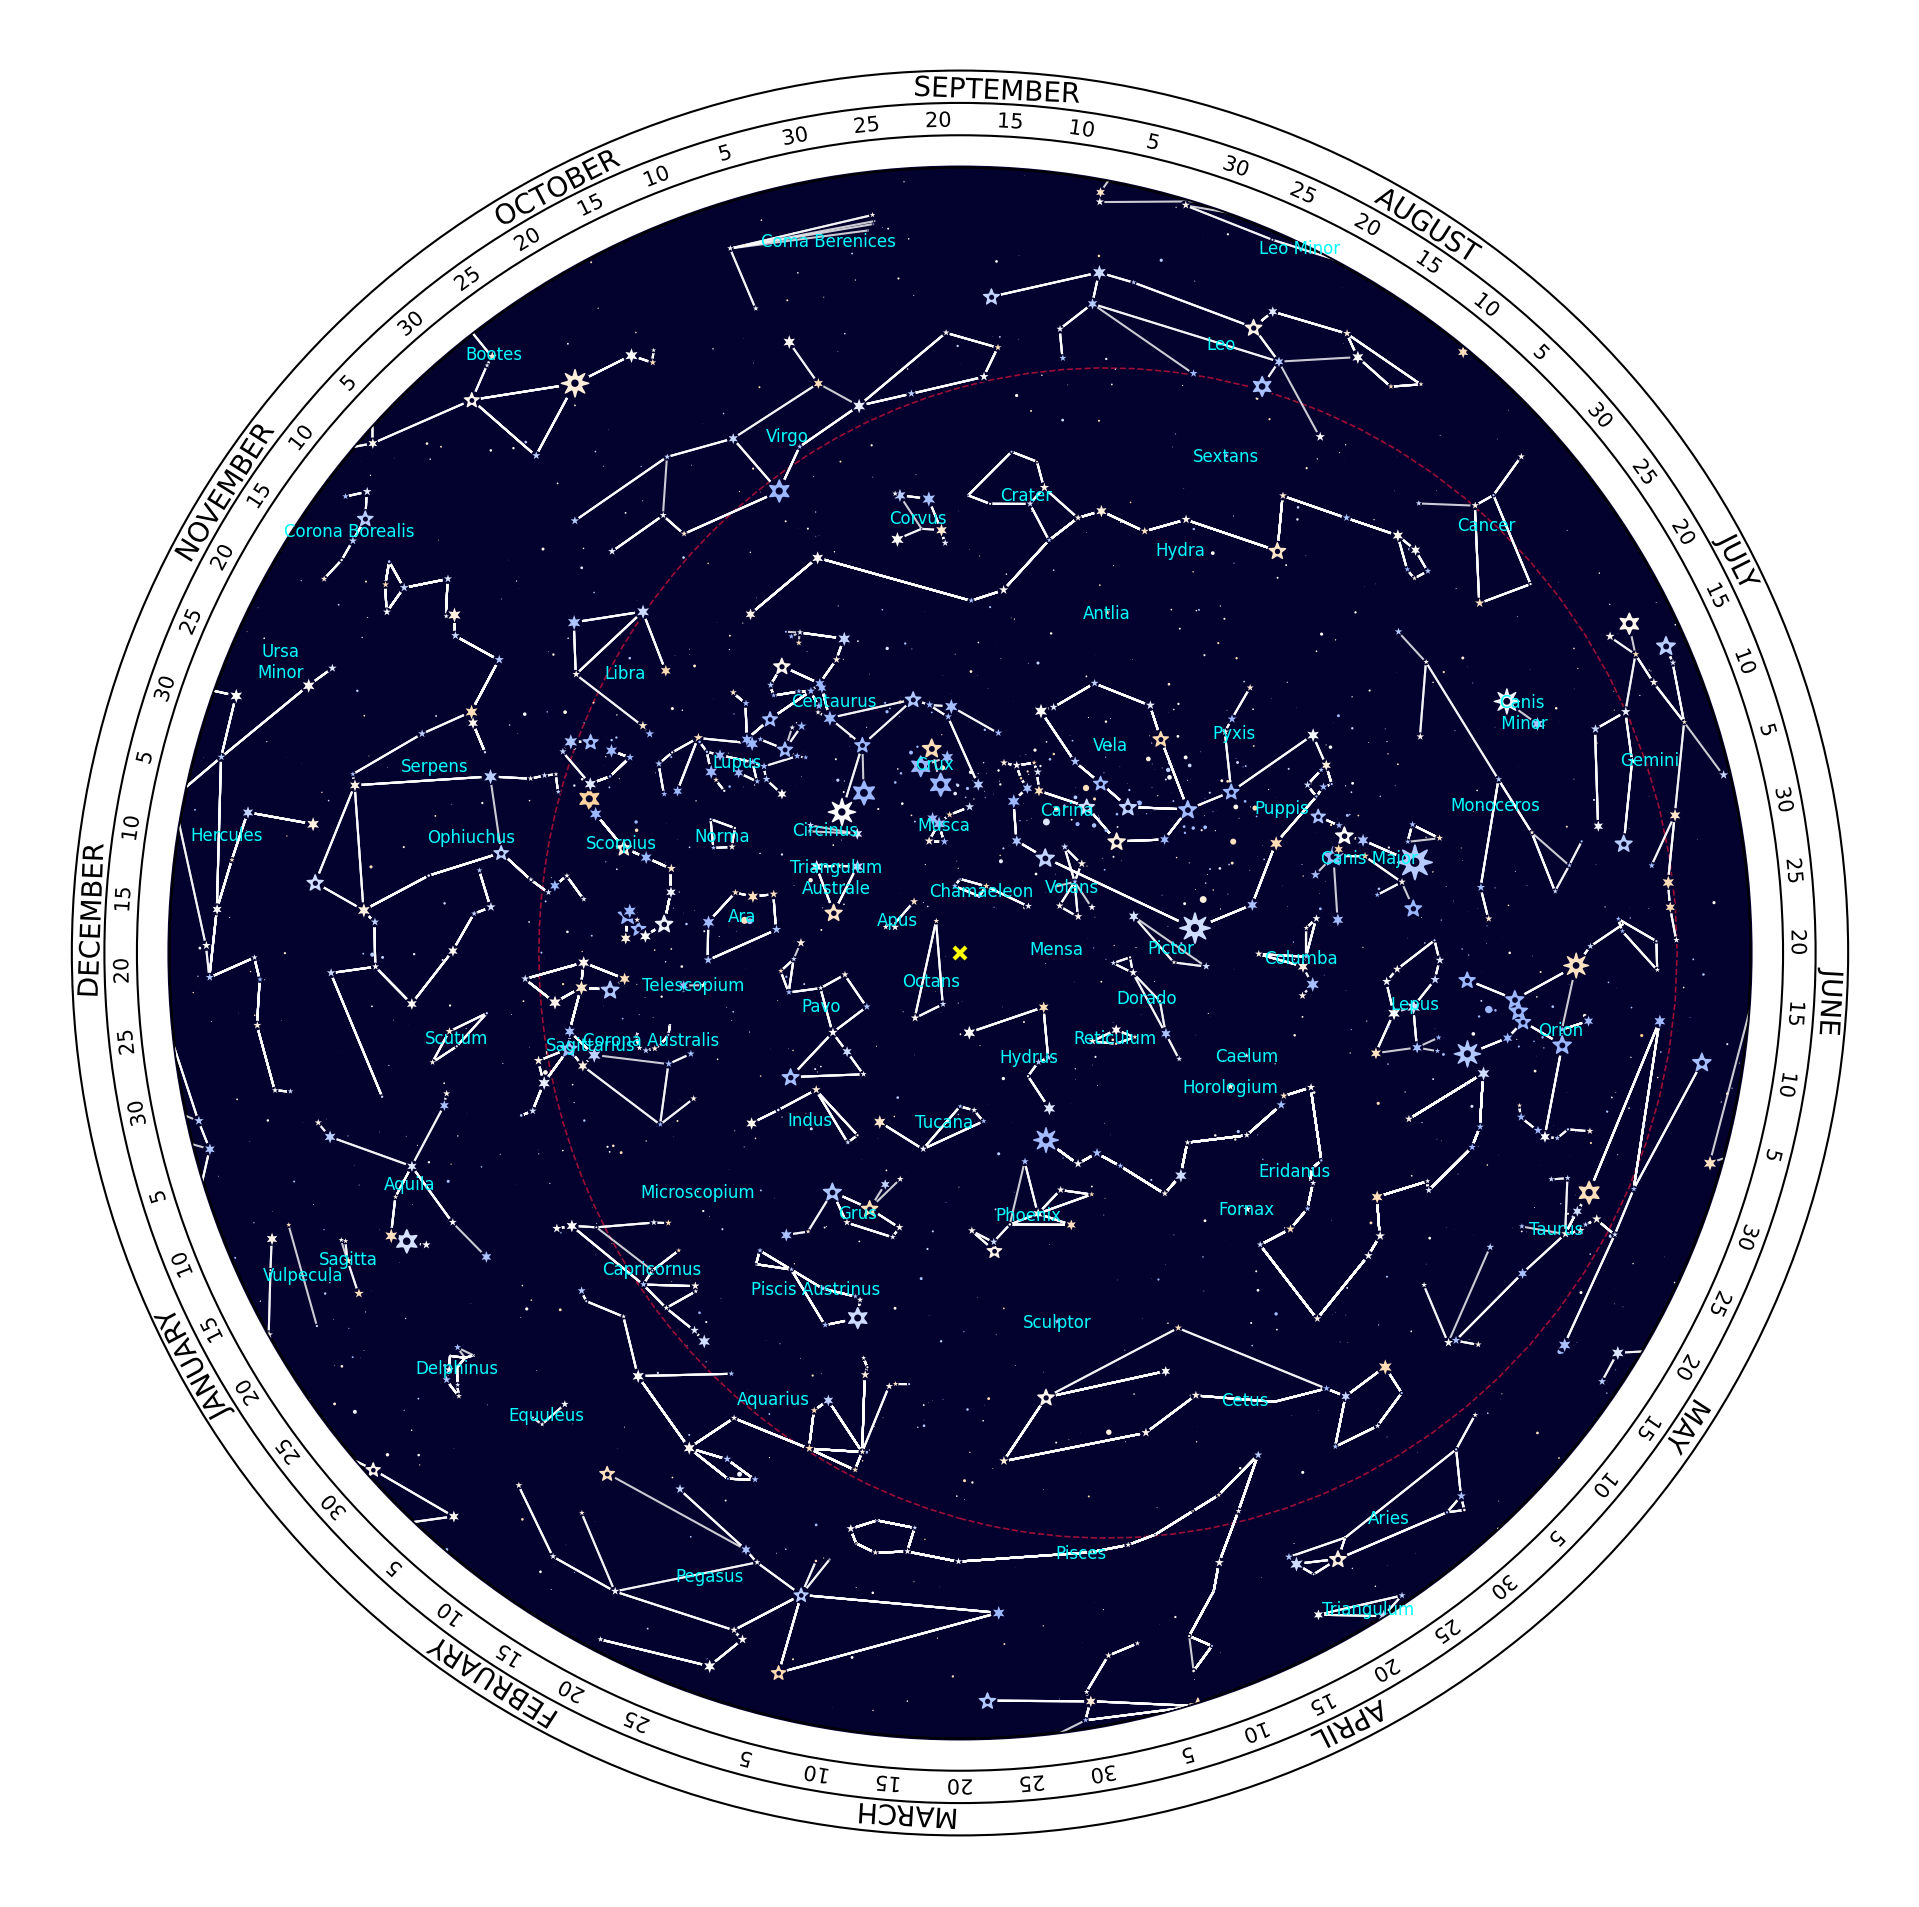

In [17]:
harey.polar_map(FOV=250, pole='S', GRID=False, CON_LINES=True, ADD_CALENDAR=True, mode='azimuth', star_size=50, CON_NAMES=True, font_sizes=(1,2,4), STAR_COLORS=True)